In [ ]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
iris.feature_names
df = pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()
df['target'] = iris.target
df.head()
df[df.target==1].head()
df[df.target==2].head()
df['flower_name'] =df.target.apply(lambda x: iris.target_names[x])
df.head()
df[45:55]
df0 = df[:50]
df1 = df[50:100]
df2 = df[100:]

import matplotlib.pyplot as plt
%matplotlib inline
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'],color="green",marker='+')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'],color="blue",marker='.')




plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.scatter(df0['petal length (cm)'], df0['petal width (cm)'],color="green",marker='+')
plt.scatter(df1['petal length (cm)'], df1['petal width (cm)'],color="blue",marker='.')


from sklearn.model_selection import train_test_split

X = df.drop(['target','flower_name'], axis='columns')
y = df.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
len(X_train)
len(X_test)
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)


knn.fit(X_train, y_train)
knn.score(X_test, y_test)
knn.predict([[4.8,3.0,1.5,0.3]])
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm


%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))









In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("art_restoration_dataset.csv")

In [3]:
def restoration_level(x):
    if x <= 5:
        return 0
    elif x <= 10:
        return 1
    elif x <= 20:
        return 2
    else:
        return 3
df['target'] = df['damage_percent'].apply(restoration_level)

In [4]:
def level_name(x):
    if x == 0:
        return "Easy"
    elif x == 1:
        return "Moderate"
    elif x == 2:
        return "Difficult"
    else:
        return "Impossible"
df['restoration_name'] = df['target'].apply(level_name)

In [6]:
df.head()

,image_name,blur_score,brightness,contrast,edge_count,damage_percent,restoration_cost,target,restoration_name
0,07_RESTORATION_BEFORE.png,1532.876678,136.902710,82.433736,4140,8.280,249.051943,1,Moderate
1,alex-before.jpg,804.065380,87.157150,41.099469,3257,6.514,196.662135,1,Moderate
2,angel.jpg,469.078146,147.353027,44.194559,2796,5.592,169.887306,1,Moderate
3,ArchimedesConservation_05-before.png,701.245648,58.590363,34.799702,2803,5.606,169.604003,1,Moderate
4,arena-before.jpg,89.401504,85.312286,18.232274,635,1.270,49.161763,0,Easy


In [7]:
df0 = df[df.target == 0]
df1 = df[df.target == 1]
df2 = df[df.target == 2]
df3 = df[df.target == 3]


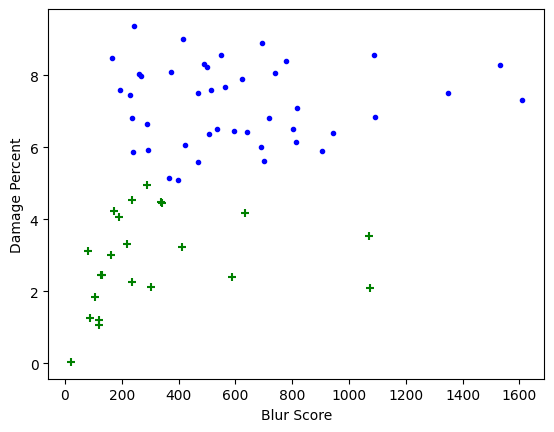

In [10]:
plt.xlabel('Blur Score')
plt.ylabel('Damage Percent')
plt.scatter(df0['blur_score'],df0['damage_percent'],color="green",marker='+')
plt.scatter(df1['blur_score'],df1['damage_percent'],color="blue",marker='.')
plt.show()

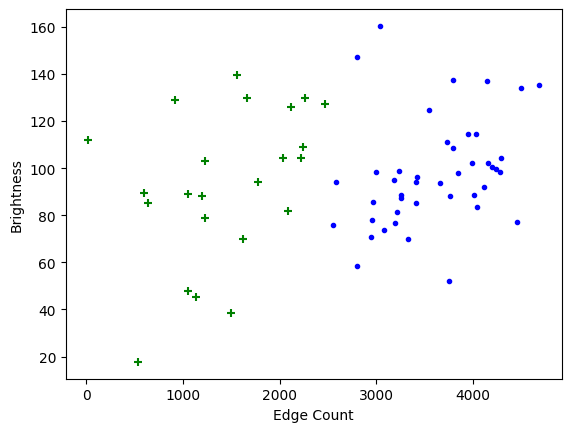

In [11]:
plt.xlabel('Edge Count')
plt.ylabel('Brightness')
plt.scatter(df0['edge_count'],df0['brightness'],color="green",marker='+')
plt.scatter(df1['edge_count'],df1['brightness'],color="blue",marker='.')
plt.show()

In [14]:
x = df[['damage_percent','blur_score','edge_count','brightness']]
y = df.target

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train, y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
knn.score(x_test, y_test)

0.9583333333333334

In [18]:
knn.predict([[8, 1500, 4000, 120]])

c:\Users\sanjay\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [24]:
from sklearn.metrics import confusion_matrix
r= knn.predict(x_test)
cc=confusion_matrix(y_test,r)
cc

array([[5, 0, 0, 0],
       [0, 9, 0, 0],
       [0, 0, 5, 0],
       [0, 0, 1, 4]], dtype=int64)

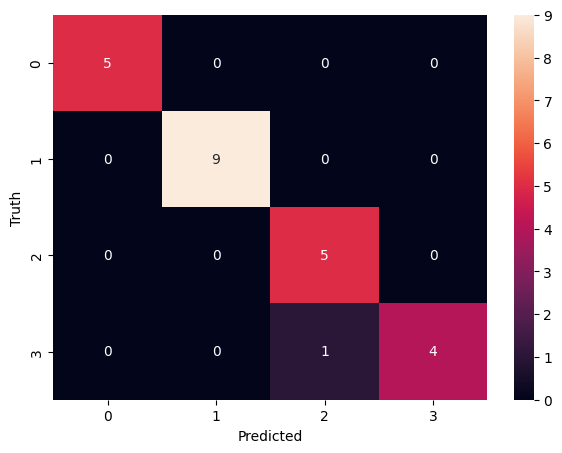

In [26]:
import seaborn as sn
plt.figure(figsize=(7,5))
sn.heatmap(cc,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [28]:

from sklearn.metrics import classification_report
print(classification_report(y_test,r))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9
           2       0.83      1.00      0.91         5
           3       1.00      0.80      0.89         5

    accuracy                           0.96        24
   macro avg       0.96      0.95      0.95        24
weighted avg       0.97      0.96      0.96        24

